In [5]:
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv(r"C:\Users\yogit\OneDrive\Desktop\data science\data science\Data Preprocess ML\Data Preprocess\data\Iris.csv")
df

,4.3,3,1.1,0.1,Iris-setosa
0,4.4,2.9,1.4,0.2,Iris-setosa
1,4.4,3.0,1.3,0.2,Iris-setosa
2,4.4,3.2,1.3,0.2,Iris-setosa
3,4.5,2.3,1.3,0.3,Iris-setosa
4,4.6,3.1,1.5,0.2,Iris-setosa
...,...,...,...,...,...
144,7.7,3.8,6.7,2.2,Iris-virginica
145,7.7,2.6,6.9,2.3,Iris-virginica
146,7.7,2.8,6.7,2.0,Iris-virginica
147,7.7,3.0,6.1,2.3,Iris-virginica


In [8]:
X = df.iloc[:, 1:4]
y = df.iloc[:, 4]


In [9]:
X

,3,1.1,0.1
0,2.9,1.4,0.2
1,3.0,1.3,0.2
2,3.2,1.3,0.2
3,2.3,1.3,0.3
4,3.1,1.5,0.2
...,...,...,...
144,3.8,6.7,2.2
145,2.6,6.9,2.3
146,2.8,6.7,2.0
147,3.0,6.1,2.3


In [10]:
y

0         Iris-setosa
1         Iris-setosa
2         Iris-setosa
3         Iris-setosa
4         Iris-setosa
            ...      
144    Iris-virginica
145    Iris-virginica
146    Iris-virginica
147    Iris-virginica
148    Iris-virginica
Name: Iris-setosa, Length: 149, dtype: object

In [11]:
df.head()

,4.3,3,1.1,0.1,Iris-setosa
0,4.4,2.9,1.4,0.2,Iris-setosa
1,4.4,3.0,1.3,0.2,Iris-setosa
2,4.4,3.2,1.3,0.2,Iris-setosa
3,4.5,2.3,1.3,0.3,Iris-setosa
4,4.6,3.1,1.5,0.2,Iris-setosa


In [12]:
df.tail()

,4.3,3,1.1,0.1,Iris-setosa
144,7.7,3.8,6.7,2.2,Iris-virginica
145,7.7,2.6,6.9,2.3,Iris-virginica
146,7.7,2.8,6.7,2.0,Iris-virginica
147,7.7,3.0,6.1,2.3,Iris-virginica
148,7.9,3.8,6.4,2.0,Iris-virginica


In [13]:
df.describe()

,4.3,3,1.1,0.1
count,149.000000,149.000000,149.00000,149.000000
mean,5.853691,3.054362,3.77651,1.206040
std,0.821051,0.435034,1.75674,0.760354
min,4.400000,2.000000,1.00000,0.100000
25%,5.100000,2.800000,1.60000,0.300000
50%,5.800000,3.000000,4.40000,1.300000
75%,6.400000,3.300000,5.10000,1.800000
max,7.900000,4.400000,6.90000,2.500000


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   4.3          149 non-null    float64
 1   3            149 non-null    float64
 2   1.1          149 non-null    float64
 3   0.1          149 non-null    float64
 4   Iris-setosa  149 non-null    object 
dtypes: float64(4), object(1)
memory usage: 5.9+ KB


In [15]:
df.columns

Index(['4.3', '3', '1.1', '0.1', 'Iris-setosa'], dtype='object')

In [16]:
df.isnull().sum()

4.3            0
3              0
1.1            0
0.1            0
Iris-setosa    0
dtype: int64

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:

# Different K values to test
k_values = [1, 3, 5, 7, 9]

# Store accuracy results
results = []

for k in k_values:
    
    # Create KNN model
    knn = KNeighborsClassifier(n_neighbors=k)
    
    # Train the model
    knn.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred = knn.predict(X_test_scaled)
    
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    
    # Store results
    results.append({
        "K": k,
        "Accuracy": accuracy
    })

# Convert results to Pandas DataFrame
results_df = pd.DataFrame(results)

print(results_df)

   K  Accuracy
0  1  0.900000
1  3  0.933333
2  5  0.933333
3  7  0.933333
4  9  0.933333


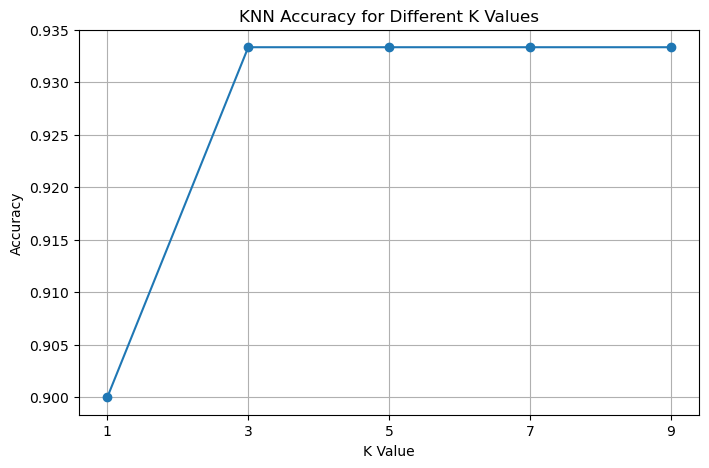

In [21]:
plt.figure(figsize=(8, 5))

plt.plot(
    results_df["K"],
    results_df["Accuracy"],
    marker="o"
)

plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy for Different K Values")

plt.xticks(k_values)
plt.grid()

plt.show()

In [22]:
# Create KNN model with K = 5
knn = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn.fit(X_train_scaled, y_train)

# Predict test data
y_pred = knn.predict(X_test_scaled)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9333333333333333


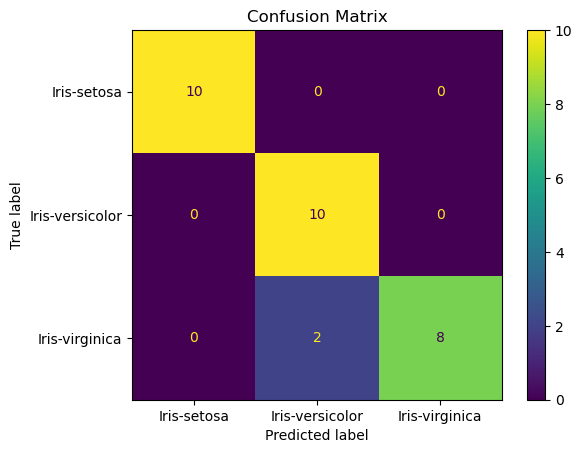

In [28]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=sorted(y.unique())
)

disp.plot()

plt.title("Confusion Matrix")

plt.show()

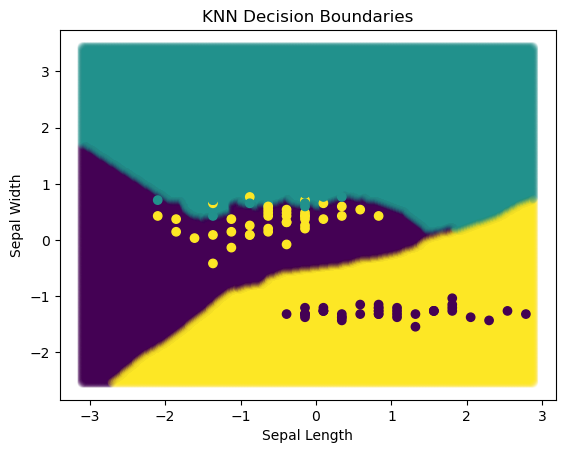

In [35]:
# Select only two features
X_two = df.iloc[:, 1:3]
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_two,
    y,
    test_size=0.2,
    random_state=42
)
# Normalize features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

# Train KNN model
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)
# Create values for the decision boundary
x_values = pd.Series(
    [X_train[:, 0].min() - 1 + i * 0.02 for i in range(300)]
)
y_values = pd.Series(
    [X_train[:, 1].min() - 1 + i * 0.02 for i in range(300)]
)

# Create grid using Pandas
grid = pd.DataFrame(
    [(x, y) for x in x_values for y in y_values],
    columns=["Feature1", "Feature2"]
)

# Predict grid points
predictions = model.predict(grid.values)

grid["Prediction"] = predictions

# Convert predictions into numbers
grid["Prediction_Code"] = pd.factorize(grid["Prediction"])[0]

# Plot decision regions
plt.scatter(
    grid["Feature1"],
    grid["Feature2"],
    c=grid["Prediction_Code"],
    alpha=0.1
)

# Plot training points
plt.scatter(
    X_train[:, 0],
    X_train[:, 1],
    c=pd.factorize(y_train)[0]
)

plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")

plt.title("KNN Decision Boundaries")

plt.show()